# Notebook 2 — Engagement Classification
**European Bank Customer Churn Analysis**

> Build four behavioural engagement profiles and measure churn dynamics across them.

---

## Setup & Data Load

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid':        True,
    'grid.color':       '#E8E6DE',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

PALETTE = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'amber':  '#EF9F27',
    'coral':  '#D85A30',
    'purple': '#7F77DD',
    'red':    '#E24B4A',
    'gray':   '#888780',
    'green':  '#639922',
    'pink':   '#D4537E',
}
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('European_Bank.csv')
churn_rate = df['Exited'].mean() * 100
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns  |  Churn rate: {churn_rate:.1f}%')

Loaded: 10,000 rows × 14 columns  |  Churn rate: 20.4%


In [3]:
# ── Pre-compute shared fields ──────────────────────────────────────────────
HIGH_BALANCE_THRESHOLD = df['Balance'].quantile(0.75)
BALANCE_THRESHOLD      = df[df['Balance'] > 0]['Balance'].median()

# Engagement profile
def classify_engagement(row):
    active   = row['IsActiveMember'] == 1
    multi    = row['NumOfProducts']  >= 2
    high_bal = row['Balance'] >= HIGH_BALANCE_THRESHOLD and row['Balance'] > 0
    if active and multi:               return 'Active Engaged'
    elif not active and not multi and row['Balance'] == 0: return 'Inactive Disengaged'
    elif active and not multi:         return 'Active Low-Product'
    elif not active and high_bal:      return 'Inactive High-Balance'
    else:                              return 'Mixed'

df['EngagementProfile']    = df.apply(classify_engagement, axis=1)
df['ProductTier']          = df['NumOfProducts'].apply(
    lambda x: 'Single (1)' if x == 1 else ('Dual (2)' if x == 2 else 'Power (3-4)'))

salary_75  = df['EstimatedSalary'].quantile(0.75)
balance_25 = df[df['Balance'] > 0]['Balance'].quantile(0.25)
df['SalaryBalanceMismatch'] = (
    (df['EstimatedSalary'] >= salary_75) &
    ((df['Balance'] == 0) | (df['Balance'] < balance_25))
)
bal_75 = df['Balance'].quantile(0.75)
sal_75 = df['EstimatedSalary'].quantile(0.75)
df['IsPremium']       = (df['Balance'] >= bal_75) & (df['EstimatedSalary'] >= sal_75)
df['IsAtRiskPremium'] = df['IsPremium'] & (df['IsActiveMember'] == 0)

def sticky_score(row):
    s = 0
    if row['IsActiveMember'] == 1:        s += 2
    if row['NumOfProducts'] >= 2:          s += 2
    if row['HasCrCard'] == 1:              s += 1
    if row['Balance'] > BALANCE_THRESHOLD: s += 2
    if row['Tenure'] >= 5:                 s += 1
    if row['CreditScore'] >= 700:          s += 1
    return s
df['StickyScore'] = df.apply(sticky_score, axis=1)
df['StickyTier']  = pd.cut(df['StickyScore'], bins=[-1,2,5,7,9],
    labels=['Low (0-2)','Medium (3-5)','High (6-7)','Very High (8-9)'])

print('Shared features computed ✓')

Shared features computed ✓


## 2.1 — Define Engagement Profiles

In [4]:
profile_summary = df.groupby('EngagementProfile').agg(
    Count        = ('Exited', 'count'),
    Churn_Rate   = ('Exited', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Balance  = ('Balance', lambda x: f"£{x.mean():,.0f}"),
    Avg_Products = ('NumOfProducts', lambda x: f"{x.mean():.2f}"),
    Active_Pct   = ('IsActiveMember', lambda x: f"{x.mean()*100:.1f}%")
).reset_index()
profile_summary['Share'] = profile_summary['Count'].apply(lambda x: f"{x/len(df)*100:.1f}%")

print(f'High-balance threshold (75th pct): £{HIGH_BALANCE_THRESHOLD:,.0f}\n')
profile_summary

High-balance threshold (75th pct): £127,644



,EngagementProfile,Count,Churn_Rate,Avg_Balance,Avg_Products,Active_Pct,Share
0,Active Engaged,2588,9.7%,"£53,071",2.07,100.0%,25.9%
1,Active Low-Product,2563,18.9%,"£98,902",1.00,100.0%,25.6%
2,Inactive Disengaged,473,47.1%,£0,1.00,0.0%,4.7%
3,Inactive High-Balance,1247,30.5%,"£148,858",1.38,0.0%,12.5%
4,Mixed,3129,22.3%,"£60,211",1.66,0.0%,31.3%


## 2.2 — Profile Size & Churn Rate

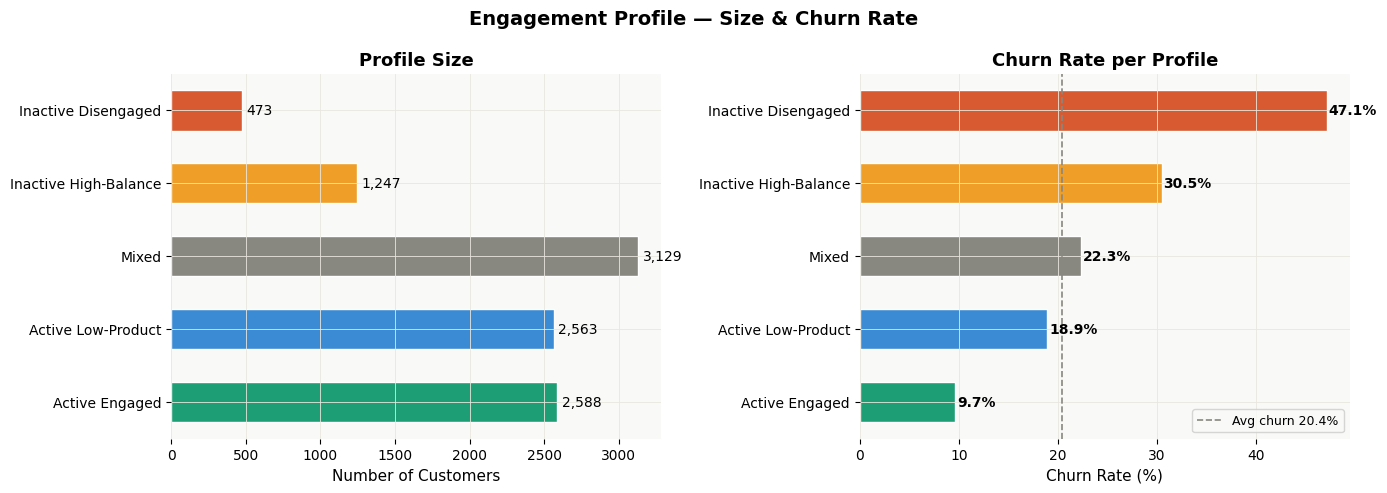

In [5]:
profile_colors = {
    'Active Engaged':        PALETTE['teal'],
    'Active Low-Product':    PALETTE['blue'],
    'Inactive High-Balance': PALETTE['amber'],
    'Inactive Disengaged':   PALETTE['coral'],
    'Mixed':                 PALETTE['gray'],
}
profile_stats = df.groupby('EngagementProfile').agg(
    count      = ('Exited', 'count'),
    churn_rate = ('Exited', 'mean')
).reset_index()
profile_stats['churn_pct'] = profile_stats['churn_rate'] * 100
profile_stats = profile_stats.sort_values('churn_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Engagement Profile — Size & Churn Rate', fontweight='bold', fontsize=14)

colors_ordered = [profile_colors.get(p, PALETTE['gray']) for p in profile_stats['EngagementProfile']]

ax = axes[0]
bars = ax.barh(profile_stats['EngagementProfile'], profile_stats['count'],
               color=colors_ordered, height=0.55, edgecolor='white')
ax.set_xlabel('Number of Customers'); ax.set_title('Profile Size'); ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)

ax2 = axes[1]
bars2 = ax2.barh(profile_stats['EngagementProfile'], profile_stats['churn_pct'],
                 color=colors_ordered, height=0.55, edgecolor='white')
ax2.axvline(churn_rate, color=PALETTE['gray'], linestyle='--', linewidth=1.2,
            label=f'Avg churn {churn_rate:.1f}%')
ax2.set_xlabel('Churn Rate (%)'); ax2.set_title('Churn Rate per Profile'); ax2.invert_yaxis()
ax2.legend(fontsize=9)
for bar in bars2:
    ax2.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_04_engagement_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 — Engagement Profile × Geography

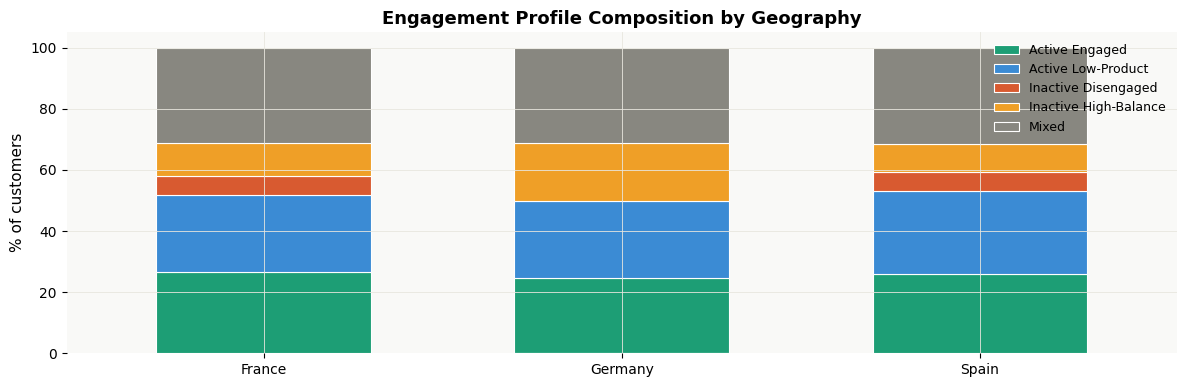

In [6]:
geo_profile = pd.crosstab(df['Geography'], df['EngagementProfile'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 4))
geo_profile.plot(kind='bar', ax=ax, stacked=True,
                 color=[profile_colors.get(c, PALETTE['gray']) for c in geo_profile.columns],
                 edgecolor='white', linewidth=0.8, width=0.6)
ax.set_title('Engagement Profile Composition by Geography', fontweight='bold')
ax.set_ylabel('% of customers'); ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right', fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('fig_05_geo_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 — Churn Rate Heatmap: Profile × Geography

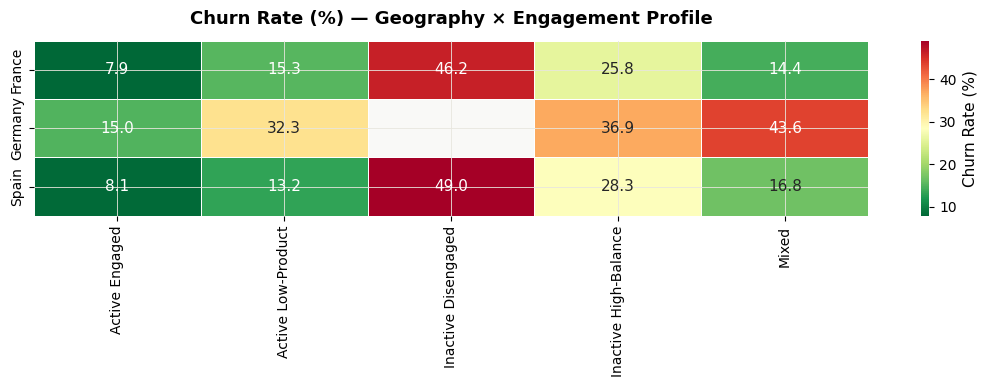

In [7]:
pivot = df.groupby(['Geography', 'EngagementProfile'])['Exited'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) — Geography × Engagement Profile', fontweight='bold', pad=12)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_05b_profile_geo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()